In [1]:
import numpy as np
import healpy as hp
from healpy.newvisufunc import projview
from astropy.table import Table

import matplotlib
from matplotlib import pyplot as plt

from Corrfunc import mocks
from Corrfunc.utils import convert_rp_pi_counts_to_wp
from scipy import constants
from scipy import stats
import scipy.interpolate as interp
from random import sample
import matplotlib.gridspec as gridspec
from Corrfunc import theory
from astropy.cosmology import FlatLambdaCDM
from Corrfunc.utils import convert_3d_counts_to_cf
import astropy.cosmology.units as cu
import astropy.units as u
import quaia
from astropy.coordinates import SkyCoord

In [2]:
matplotlib.rcParams['ytick.labelsize'] = 18
matplotlib.rcParams['xtick.labelsize'] = 18
matplotlib.rcParams['axes.labelsize'] = 22
matplotlib.rcParams['legend.fontsize'] = 18
matplotlib.rcParams['axes.titlesize'] = 20

# Check the impact of masking on clustering
## Define some global variables

In [3]:
G_lo = 20.0
NSIDE = 64

In [4]:
fn_randlo = f'../data/randoms/random_G20.0_10x.fits'
tab_randlo = Table.read(fn_randlo)
c_randlo = SkyCoord(ra=tab_randlo['ra'], dec=tab_randlo['dec'])

In [5]:
pixel_indices_randlo = hp.ang2pix(NSIDE, tab_randlo['ra'], tab_randlo['dec'], lonlat=True)

In [6]:
fn_sello = f'../data/maps/selection_function_NSIDE64_G20.0.fits'
selfunc_lo = hp.fitsfunc.read_map(fn_sello)

In [7]:
nthreads = 18

In [8]:
b_array = [0, 10, 20, 30, 40, 0]
fac_stdev_array = [1.5, 1.5, 1.45, 0.5, 0.5, 0.5] #1.45, 0.5
mask_type_array = [None, None, None, None, None, 'selfunc']

In [9]:
label = ['$b\geq{:d}^{{\circ}}$'.format(b) for b in b_array[:-1]]
label.append('$w_p\geq0.5$')

## $\xi(r)$

In [10]:
# Create the bins array
# rmin = 0.1 # 0.1 # start higher
# rmax = 180.0 # 20.0 #50.0
# nbins = 20 #90 #20
# rbins = np.logspace(np.log10(rmin), np.log10(rmax), nbins + 1) # Mpc/h https://github.com/manodeep/Corrfunc/issues/202

# # Create the bins array
rmin = 0.1 # 0.1 # start higher
rmax = 155.0 # 20.0 #50.0
nbins = 20 #90 #20
rbins = np.linspace(rmin, rmax, nbins + 1) # Mpc/h https://github.com/manodeep/Corrfunc/issues/202

Number of data sources: 755850
OrderedDict([('NAME', '\\emph{{Gaia}}--\\emph{{unWISE}} Quasar Catalog'), ('ABBRV', 'Quaia')])
Column names: <TableColumns names=('source_id','unwise_objid','redshift_quaia','redshift_quaia_err','ra','dec','l','b','phot_g_mean_mag','phot_bp_mean_mag','phot_rp_mean_mag','mag_w1_vg','mag_w2_vg','pm','pmra','pmdec','pmra_error','pmdec_error')>


/oak/stanford/orgs/kipac/users/mahlet/quaia_bias/notebooks/quaia.py:108: RuntimeWarning: invalid value encountered in true_divide
  map_selfunc_lo = map_gcatlo/selfunc_lo
[Warning] The CPU supports AVX512F but the compiler does not.  Can you try another compiler?


Number of data sources: 755850
OrderedDict([('NAME', '\\emph{{Gaia}}--\\emph{{unWISE}} Quasar Catalog'), ('ABBRV', 'Quaia')])
Column names: <TableColumns names=('source_id','unwise_objid','redshift_quaia','redshift_quaia_err','ra','dec','l','b','phot_g_mean_mag','phot_bp_mean_mag','phot_rp_mean_mag','mag_w1_vg','mag_w2_vg','pm','pmra','pmdec','pmra_error','pmdec_error')>


/oak/stanford/orgs/kipac/users/mahlet/quaia_bias/notebooks/quaia.py:108: RuntimeWarning: invalid value encountered in true_divide
  map_selfunc_lo = map_gcatlo/selfunc_lo


Number of data sources: 755850
OrderedDict([('NAME', '\\emph{{Gaia}}--\\emph{{unWISE}} Quasar Catalog'), ('ABBRV', 'Quaia')])
Column names: <TableColumns names=('source_id','unwise_objid','redshift_quaia','redshift_quaia_err','ra','dec','l','b','phot_g_mean_mag','phot_bp_mean_mag','phot_rp_mean_mag','mag_w1_vg','mag_w2_vg','pm','pmra','pmdec','pmra_error','pmdec_error')>


...

/oak/stanford/orgs/kipac/users/mahlet/quaia_bias/notebooks/quaia.py:108: RuntimeWarning: invalid value encountered in true_divide
  map_selfunc_lo = map_gcatlo/selfunc_lo


Number of data sources: 755850
OrderedDict([('NAME', '\\emph{{Gaia}}--\\emph{{unWISE}} Quasar Catalog'), ('ABBRV', 'Quaia')])
Column names: <TableColumns names=('source_id','unwise_objid','redshift_quaia','redshift_quaia_err','ra','dec','l','b','phot_g_mean_mag','phot_bp_mean_mag','phot_rp_mean_mag','mag_w1_vg','mag_w2_vg','pm','pmra','pmdec','pmra_error','pmdec_error')>


/oak/stanford/orgs/kipac/users/mahlet/quaia_bias/notebooks/quaia.py:108: RuntimeWarning: invalid value encountered in true_divide
  map_selfunc_lo = map_gcatlo/selfunc_lo


Number of data sources: 755850
OrderedDict([('NAME', '\\emph{{Gaia}}--\\emph{{unWISE}} Quasar Catalog'), ('ABBRV', 'Quaia')])
Column names: <TableColumns names=('source_id','unwise_objid','redshift_quaia','redshift_quaia_err','ra','dec','l','b','phot_g_mean_mag','phot_bp_mean_mag','phot_rp_mean_mag','mag_w1_vg','mag_w2_vg','pm','pmra','pmdec','pmra_error','pmdec_error')>


/oak/stanford/orgs/kipac/users/mahlet/quaia_bias/notebooks/quaia.py:108: RuntimeWarning: invalid value encountered in true_divide
  map_selfunc_lo = map_gcatlo/selfunc_lo


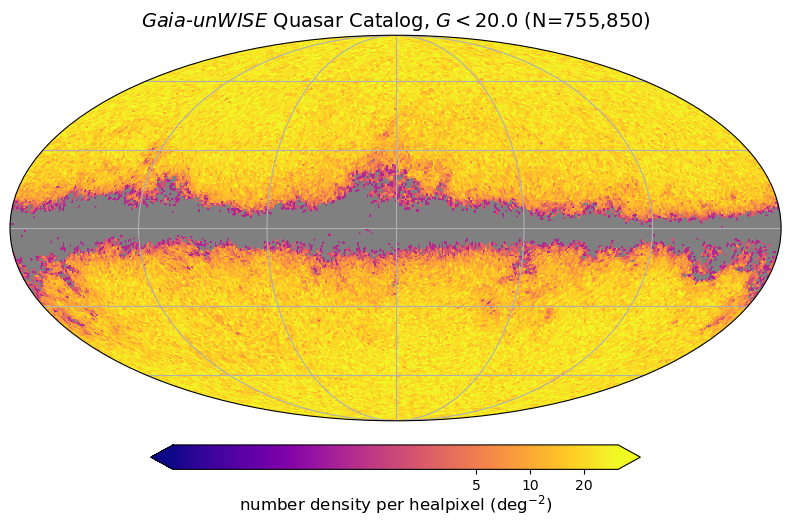

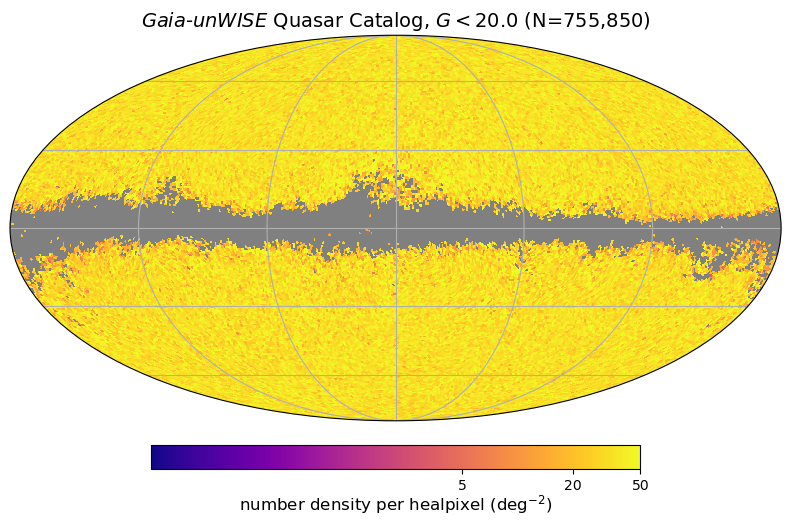

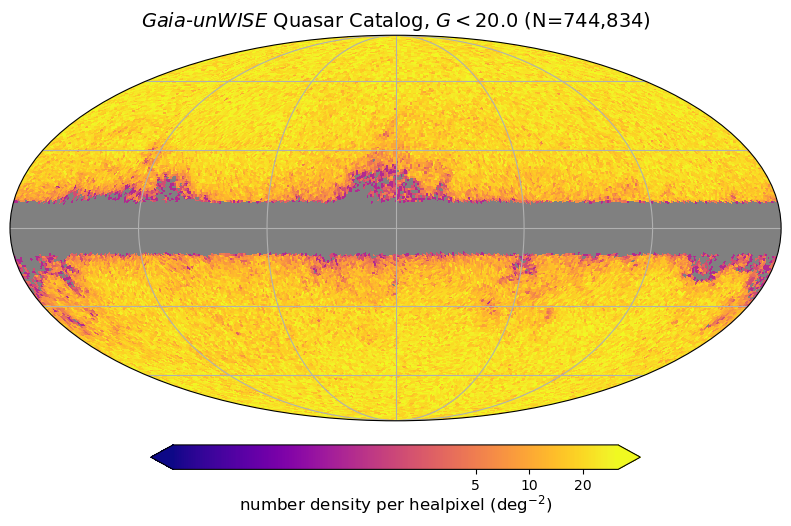

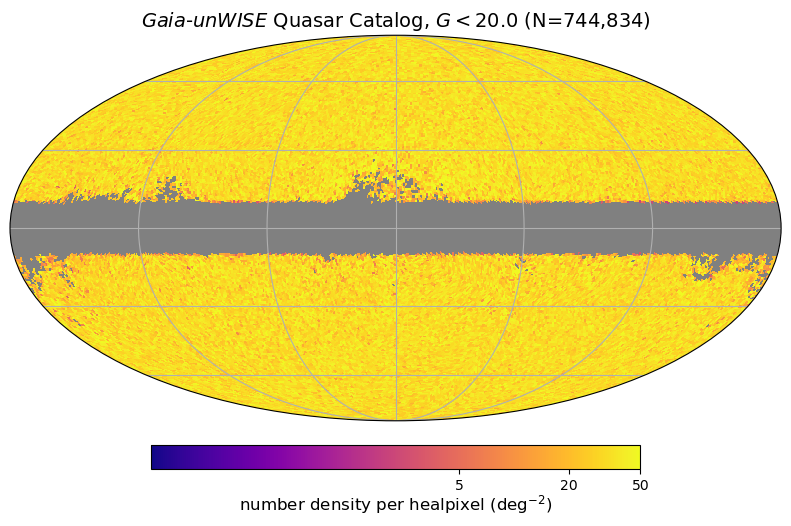

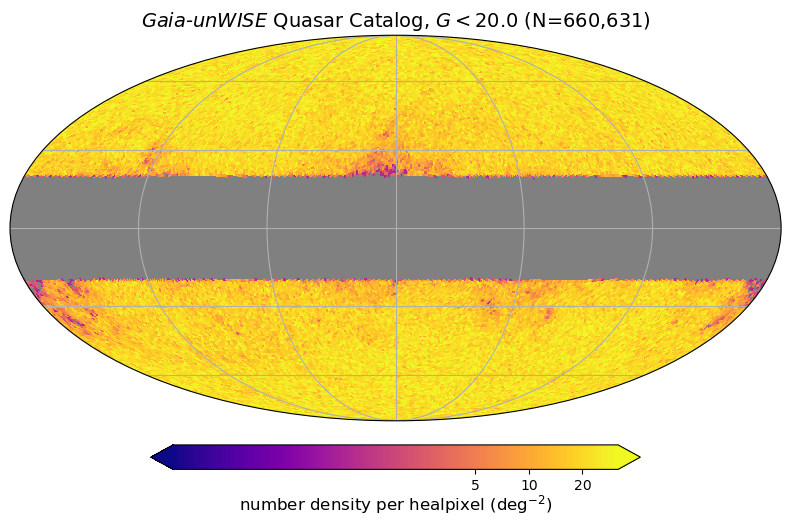

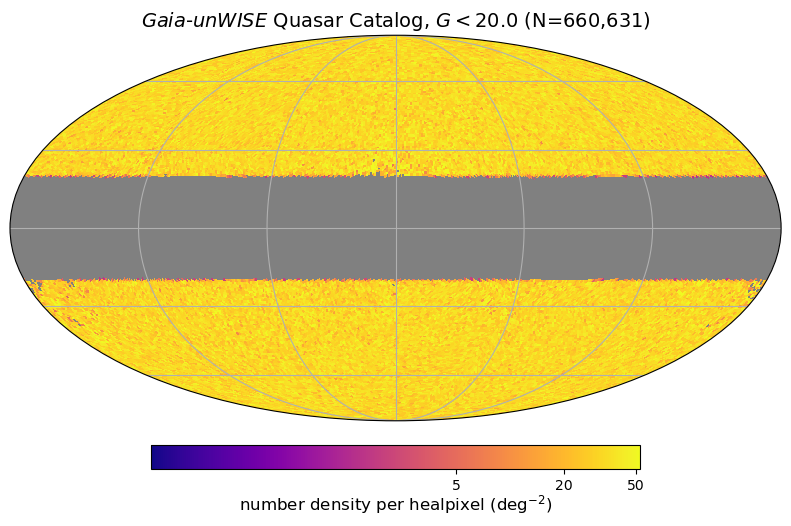

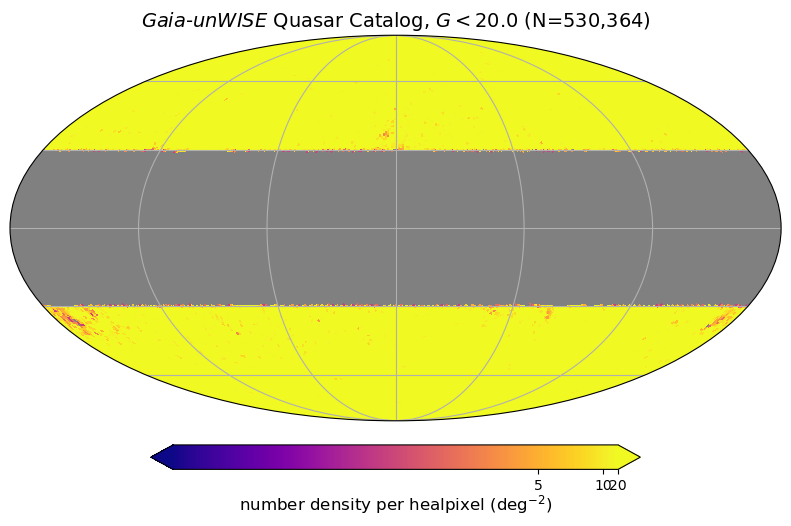

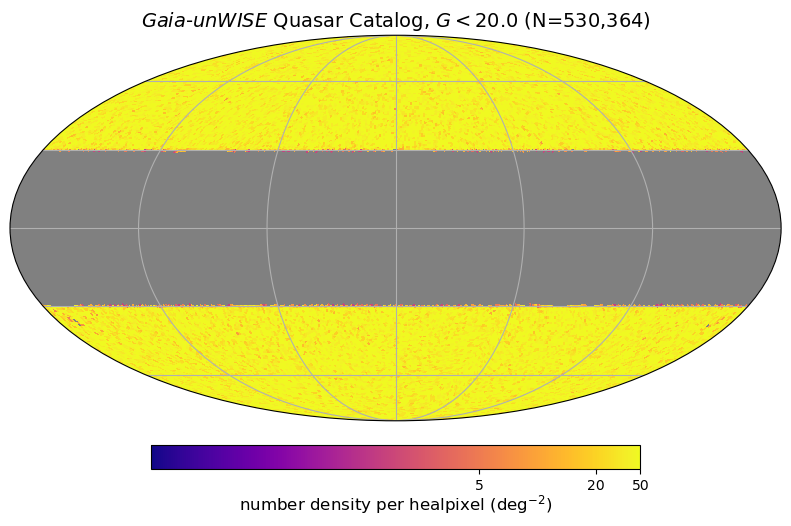

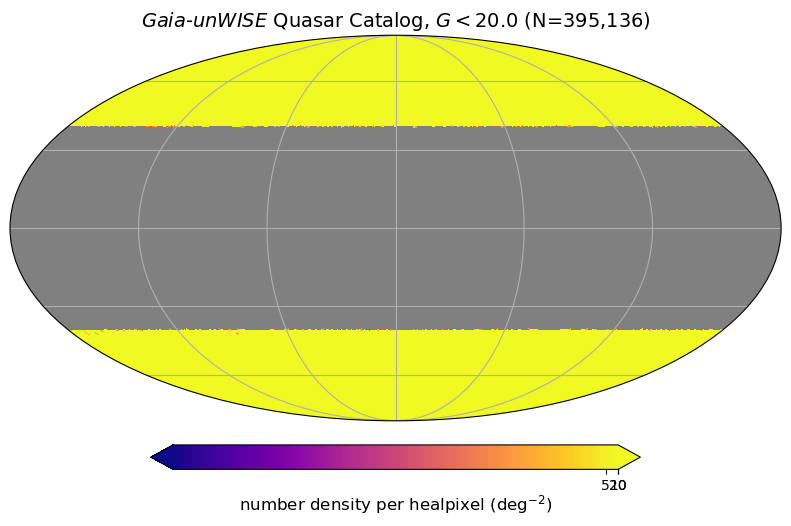

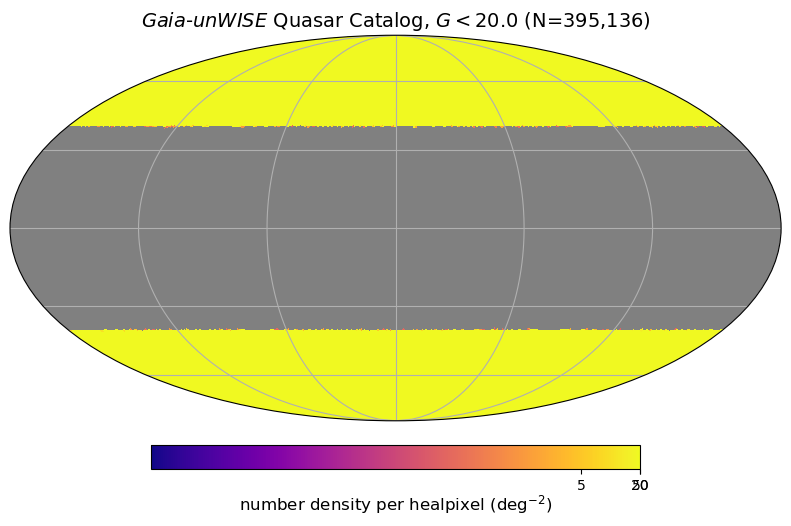

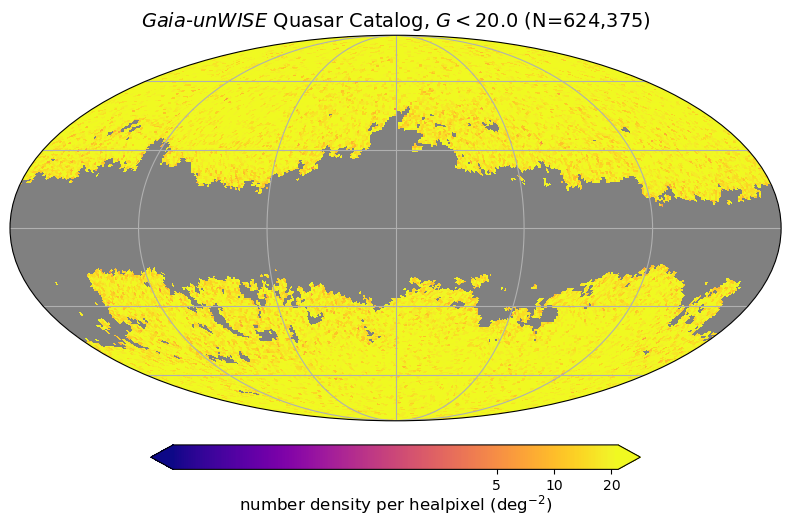

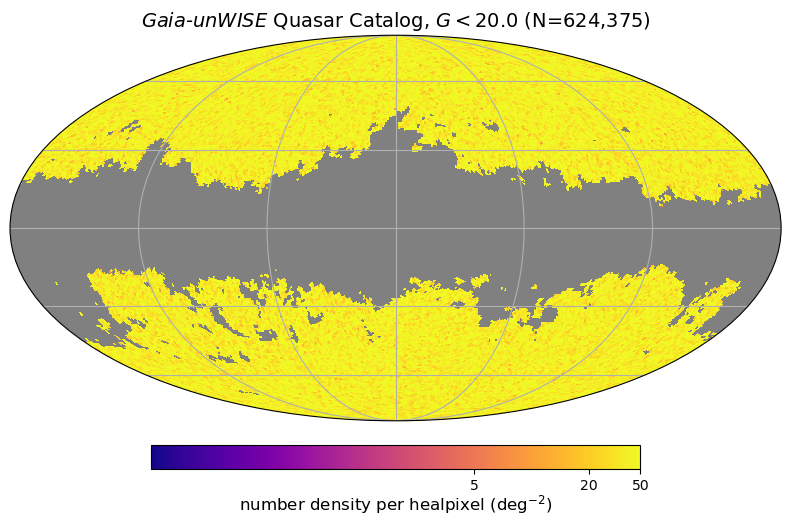

In [11]:
cf_data_b_array, ravg_data_b_array  = [], []
for i in range(len(b_array)):
    
    tab_datalo, pixel_indices_datalo_b, N_datalo_b, mask_datalo_b = quaia.read(f'../data/quaia_G20.0.fits', G_lo, fn_sello, b = b_array[i],
                                                                      mask_type = mask_type_array[i], selfunc_lo = selfunc_lo, plot = True, 
                                                                      fac_stdev = fac_stdev_array[i])

    # if not np.array_equal(selfunc_lo_array[i], None):
    if mask_type_array[i]==None:
        mask_randlo_b = np.abs(c_randlo.galactic.b.value)>=b_array[i] # use galactic coordinates from data 
        # pixel_indices_randlo_b = hp.ang2pix(NSIDE, tab_randlo['ra'][mask_randlo_b], tab_randlo['dec'][mask_randlo_b], lonlat=True)
    else:
        mask_randlo_b = selfunc_lo[pixel_indices_randlo]>=0.5
        # pixel_indices_randlo_b = pixel_indices_randlo[mask_randlo_b]
        
    N_randlo_b = len(tab_randlo['ra'][mask_randlo_b])
    key_b = quaia.z_dist(tab_datalo, tab_randlo, mask_datalo_b, mask_randlo_b, N_datalo_b, N_randlo_b, b = b_array[i], mask_type = mask_type_array[i])
    
    # pixel_indices_randlo_b = hp.ang2pix(NSIDE, tab_randlo['ra'][mask_randlo_b], tab_randlo['dec'][mask_randlo_b], lonlat=True)
    cf_data_b, ravg_data_b = quaia.xi_r(tab_datalo[mask_datalo_b], tab_randlo[mask_randlo_b], 
                                        # selfunc_lo, pixel_indices_datalo_b, pixel_indices_randlo_b, 
                                        N_datalo_b, N_randlo_b, key_b, nthreads = nthreads, rbins = rbins)
    cf_data_b_array.append(cf_data_b)
    ravg_data_b_array.append(ravg_data_b)

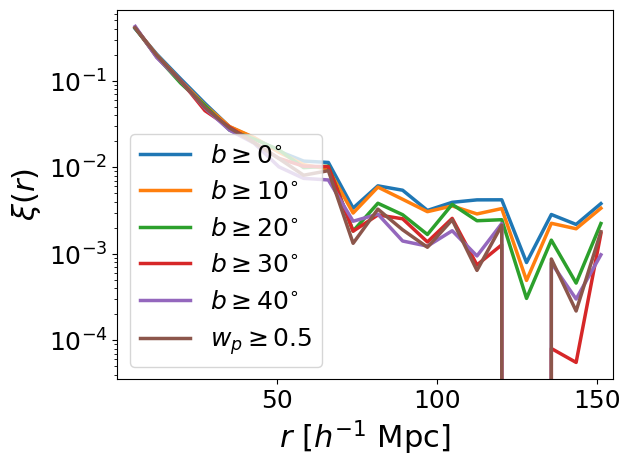

In [12]:
for i in range(len(b_array)):
    plt.plot(ravg_data_b_array[i], cf_data_b_array[i], label = label[i], linewidth = 2.5)
plt.xlabel(r'$r$ $[h^{-1}$ Mpc]') # projected
plt.ylabel(r"$\xi(r)$")
# plt.xscale('log')
plt.yscale('log')
plt.xlim(rmin, rmax)
plt.legend() #(1, 0.25, 0.5, 0.5))
plt.show()

## $w_p(r_p)$

In [13]:
# Create the bins array
# rmin = 0.15 # 0.5 # 0.1 # start higher
# rmax = 85 # 60.0 # 20.0 
# nbins = 20 
# rbins = np.logspace(np.log10(rmin), np.log10(rmax), nbins + 1) # Mpc/h https://github.com/manodeep/Corrfunc/issues/202

# Create the bins array
# rmin = 0.15 # 0.5 # 0.1 # start higher
# rmax = 240 # 120 #85 # 60.0 # 20.0 
# nbins = 20 
# rbins = np.logspace(np.log10(rmin), np.log10(rmax), nbins + 1) # Mpc/h https://github.com/manodeep/Corrfunc/issues/202

rmin = 0.15 # 0.5 # 0.1 # start higher
rmax = 210 # 120 #85 # 60.0 # 20.0 
nbins = 20 
rbins = np.linspace(rmin, rmax, nbins + 1) # Mpc/h https://github.com/manodeep/Corrfunc/issues/202

In [14]:
pimax = 80 # 40 # 5000.0 # 40.0

In [15]:
wp_data_b_array, rpavg_data_b_array = [], []
for i in range(len(b_array)):
    
    _, pixel_indices_datalo_b, N_datalo_b, mask_datalo_b = quaia.read(f'../data/quaia_G20.0.fits', G_lo, fn_sello, b = b_array[i],
                                                                      mask_type = mask_type_array[i], selfunc_lo = selfunc_lo, 
                                                                      fac_stdev = fac_stdev_array[i])

    if mask_type_array[i]==None:
        mask_randlo_b = np.abs(c_randlo.galactic.b.value)>=b_array[i] # use galactic coordinates from data 
        # pixel_indices_randlo_b = hp.ang2pix(NSIDE, tab_randlo['ra'][mask_randlo_b], tab_randlo['dec'][mask_randlo_b], lonlat=True)
    else:
        mask_randlo_b = selfunc_lo[pixel_indices_randlo]>=0.5
        # pixel_indices_randlo_b = pixel_indices_randlo[mask_randlo_b]
        
    N_randlo_b = len(tab_randlo['ra'][mask_randlo_b])
    key_b = quaia.z_dist(tab_datalo, tab_randlo, mask_datalo_b, mask_randlo_b, N_datalo_b, N_randlo_b, b = b_array[i], mask_type = mask_type_array[i])
    
    wp_data_b, rpavg_data_b = quaia.wp_rp(tab_datalo[mask_datalo_b], tab_randlo[mask_randlo_b], 
                                          # selfunc_lo, pixel_indices_datalo_b, pixel_indices_randlo_b, 
                                          N_datalo_b, N_randlo_b, key_b, nthreads = nthreads, rbins = rbins, nbins = nbins, 
                                          pimax = pimax)
    
    wp_data_b_array.append(wp_data_b)
    rpavg_data_b_array.append(rpavg_data_b)

Number of data sources: 755850
OrderedDict([('NAME', '\\emph{{Gaia}}--\\emph{{unWISE}} Quasar Catalog'), ('ABBRV', 'Quaia')])
Column names: <TableColumns names=('source_id','unwise_objid','redshift_quaia','redshift_quaia_err','ra','dec','l','b','phot_g_mean_mag','phot_bp_mean_mag','phot_rp_mean_mag','mag_w1_vg','mag_w2_vg','pm','pmra','pmdec','pmra_error','pmdec_error')>


[Warning] The CPU supports AVX512F but the compiler does not.  Can you try another compiler?
/home/groups/tabel/mahlet/quaia-env/lib/python3.10/site-packages/Corrfunc/utils.py:918: UserWarning: One or more input array has non-native endianness!  A copy will be made with the correct endianness.
  warnings.warn("One or more input array has non-native endianness!  A copy will"\


Number of data sources: 755850
OrderedDict([('NAME', '\\emph{{Gaia}}--\\emph{{unWISE}} Quasar Catalog'), ('ABBRV', 'Quaia')])
Column names: <TableColumns names=('source_id','unwise_objid','redshift_quaia','redshift_quaia_err','ra','dec','l','b','phot_g_mean_mag','phot_bp_mean_mag','phot_rp_mean_mag','mag_w1_vg','mag_w2_vg','pm','pmra','pmdec','pmra_error','pmdec_error')>


/home/groups/tabel/mahlet/quaia-env/lib/python3.10/site-packages/Corrfunc/utils.py:918: UserWarning: One or more input array has non-native endianness!  A copy will be made with the correct endianness.
  warnings.warn("One or more input array has non-native endianness!  A copy will"\


Number of data sources: 755850
OrderedDict([('NAME', '\\emph{{Gaia}}--\\emph{{unWISE}} Quasar Catalog'), ('ABBRV', 'Quaia')])
Column names: <TableColumns names=('source_id','unwise_objid','redshift_quaia','redshift_quaia_err','ra','dec','l','b','phot_g_mean_mag','phot_bp_mean_mag','phot_rp_mean_mag','mag_w1_vg','mag_w2_vg','pm','pmra','pmdec','pmra_error','pmdec_error')>


...

/home/groups/tabel/mahlet/quaia-env/lib/python3.10/site-packages/Corrfunc/utils.py:918: UserWarning: One or more input array has non-native endianness!  A copy will be made with the correct endianness.
  warnings.warn("One or more input array has non-native endianness!  A copy will"\


Number of data sources: 755850
OrderedDict([('NAME', '\\emph{{Gaia}}--\\emph{{unWISE}} Quasar Catalog'), ('ABBRV', 'Quaia')])
Column names: <TableColumns names=('source_id','unwise_objid','redshift_quaia','redshift_quaia_err','ra','dec','l','b','phot_g_mean_mag','phot_bp_mean_mag','phot_rp_mean_mag','mag_w1_vg','mag_w2_vg','pm','pmra','pmdec','pmra_error','pmdec_error')>


/home/groups/tabel/mahlet/quaia-env/lib/python3.10/site-packages/Corrfunc/utils.py:918: UserWarning: One or more input array has non-native endianness!  A copy will be made with the correct endianness.
  warnings.warn("One or more input array has non-native endianness!  A copy will"\


Number of data sources: 755850
OrderedDict([('NAME', '\\emph{{Gaia}}--\\emph{{unWISE}} Quasar Catalog'), ('ABBRV', 'Quaia')])
Column names: <TableColumns names=('source_id','unwise_objid','redshift_quaia','redshift_quaia_err','ra','dec','l','b','phot_g_mean_mag','phot_bp_mean_mag','phot_rp_mean_mag','mag_w1_vg','mag_w2_vg','pm','pmra','pmdec','pmra_error','pmdec_error')>


/home/groups/tabel/mahlet/quaia-env/lib/python3.10/site-packages/Corrfunc/utils.py:918: UserWarning: One or more input array has non-native endianness!  A copy will be made with the correct endianness.
  warnings.warn("One or more input array has non-native endianness!  A copy will"\


In [ ]:
for i in range(len(b_array)):
    plt.plot(rpavg_data_b_array[i], wp_data_b_array[i], label = label[i], linewidth = 2.5)
plt.xlabel(r'$r_{p}$ $[h^{-1}$ Mpc]') # projected
plt.ylabel("$w_p$ $[h^{-1}$ Mpc]")
# plt.xscale('log')
plt.xlim(rmin, rmax)
plt.yscale('log')
plt.legend()
plt.show()

## $w(\theta)$

In [17]:
# Create the bins array
thetabins = np.logspace(np.log10(0.1), np.log10(10), 15) # (np.log10(0.15), np.log10(35), 15) # (np.log10(0.1), np.log10(10.0), 15)

In [18]:
w_data_b_array = []
for i in range(len(b_array)):
    
    _, pixel_indices_datalo_b, N_datalo_b, mask_datalo_b = quaia.read(f'../data/quaia_G20.0.fits', G_lo, fn_sello, b = b_array[i],
                                                                      mask_type = mask_type_array[i], selfunc_lo = selfunc_lo,
                                                                      fac_stdev = fac_stdev_array[i])

    if mask_type_array[i]==None:
        mask_randlo_b = np.abs(c_randlo.galactic.b.value)>=b_array[i] # use galactic coordinates from data 
        # pixel_indices_randlo_b = hp.ang2pix(NSIDE, tab_randlo['ra'][mask_randlo_b], tab_randlo['dec'][mask_randlo_b], lonlat=True)
    else:
        mask_randlo_b = selfunc_lo[pixel_indices_randlo]>=0.5
        # pixel_indices_randlo_b = pixel_indices_randlo[mask_randlo_b]
        
    N_randlo_b = len(tab_randlo['ra'][mask_randlo_b])
    w_data_b = quaia.w_theta(tab_datalo[mask_datalo_b], tab_randlo[mask_randlo_b], 
                             # selfunc_lo, pixel_indices_datalo_b, pixel_indices_randlo_b, 
                        N_datalo_b, N_randlo_b, nthreads = nthreads, thetabins = thetabins)
    
    w_data_b_array.append(w_data_b)

Number of data sources: 755850
OrderedDict([('NAME', '\\emph{{Gaia}}--\\emph{{unWISE}} Quasar Catalog'), ('ABBRV', 'Quaia')])
Column names: <TableColumns names=('source_id','unwise_objid','redshift_quaia','redshift_quaia_err','ra','dec','l','b','phot_g_mean_mag','phot_bp_mean_mag','phot_rp_mean_mag','mag_w1_vg','mag_w2_vg','pm','pmra','pmdec','pmra_error','pmdec_error')>
Number of data sources: 755850
OrderedDict([('NAME', '\\emph{{Gaia}}--\\emph{{unWISE}} Quasar Catalog'), ('ABBRV', 'Quaia')])
Column names: <TableColumns names=('source_id','unwise_objid','redshift_quaia','redshift_quaia_err','ra','dec','l','b','phot_g_mean_mag','phot_bp_mean_mag','phot_rp_mean_mag','mag_w1_vg','mag_w2_vg','pm','pmra','pmdec','pmra_error','pmdec_error')>
Number of data sources: 755850
OrderedDict([('NAME', '\\emph{{Gaia}}--\\emph{{unWISE}} Quasar Catalog'), ('ABBRV', 'Quaia')])
Column names: <TableColumns names=('source_id','unwise_objid','redshift_quaia','redshift_quaia_err','ra','dec','l','b','phot_g

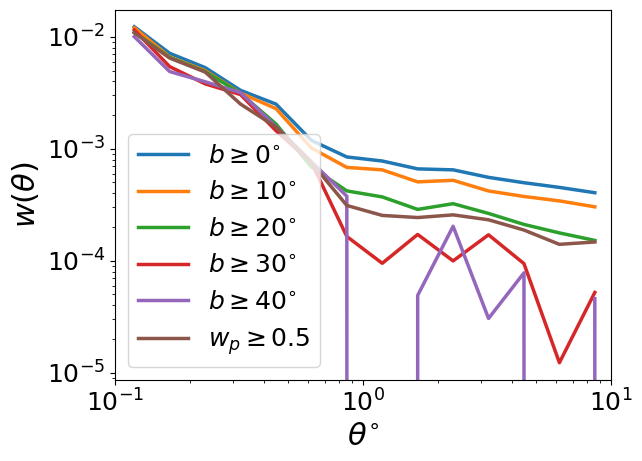

In [19]:
for i in range(len(b_array)):
    plt.plot(quaia.recenter(thetabins), w_data_b_array[i], label = label[i],linewidth = 2.5)
plt.xlabel(r'$\theta^{\circ}$')
plt.ylabel(r"$w(\theta)$")
plt.xscale('log')
plt.yscale('log')
plt.legend()
plt.xlim(thetabins[0], thetabins[-1]) # bbox_to_anchor=(1, 0.25, 0.5, 0.5)
plt.show()

## Debug colormap

In [ ]:
tab_datalo, pixel_indices_datalo_b, N_datalo_b, mask_datalo_b, map_gcatlo = quaia.read(f'../data/quaia_G20.0.fits', G_lo,
                                                                           fn_sello, b = 40, plot = True, fac_stdev = 0.5)

mask_randlo_b = np.abs(c_randlo.galactic.b.value)>=40 # use galactic coordinates from data 
N_randlo_b = len(tab_randlo['ra'][mask_randlo_b])
key = quaia.z_dist(tab_datalo, tab_randlo, mask_datalo_b, mask_randlo_b, N_datalo_b, N_randlo_b, b = 40)

pixel_indices_randlo_b = hp.ang2pix(NSIDE, tab_randlo['ra'][mask_randlo_b], tab_randlo['dec'][mask_randlo_b], lonlat=True)
cf_data_b, ravg_data_b = quaia.xi_r(tab_datalo[mask_datalo_b], tab_randlo[mask_randlo_b], selfunc_lo, pixel_indices_datalo_b, 
                                    pixel_indices_randlo_b, N_datalo_b, N_randlo_b, key, nthreads = nthreads, rbins = rbins)

In [ ]:
plt.hist(map_gcatlo)
plt.xlabel('pixel bin count')
plt.show()

In [ ]:
plt.plot(ravg_data_b, cf_data_b, label = '$b\geq{:d}^{{\circ}}$'.format(40),linewidth = 2.5)
plt.xlabel(r'$r$ $[h^{-1}$ Mpc]') # projected
plt.ylabel(r"$\xi(r)$")
plt.xscale('log')
plt.yscale('log')
plt.xlim(rmin, rmax)
plt.legend() #(1, 0.25, 0.5, 0.5))
plt.show()

In [ ]:
cf_data_b_array, ravg_data_b_array, map_gcatlo_b_array  = [], [], []
for i in range(len(b_array)):
    
    tab_datalo, pixel_indices_datalo_b, N_datalo_b, mask_datalo_b, map_gcatlo_b = quaia.read(f'../data/quaia_G20.0.fits', G_lo, fn_sello, 
                                                                                             b = b_array[i], plot = True, 
                                                                                             fac_stdev = fac_stdev_array[i])

    # if not np.array_equal(selfunc_lo_array[i], None):
    if mask_type_array[i]==None:
        mask_randlo_b = np.abs(c_randlo.galactic.b.value)>=b_array[i] # use galactic coordinates from data 
        pixel_indices_randlo_b = hp.ang2pix(NSIDE, tab_randlo['ra'][mask_randlo_b], tab_randlo['dec'][mask_randlo_b], lonlat=True)
    else:
        mask_randlo_b = selfunc_lo[pixel_indices_randlo]>=0.5
        pixel_indices_randlo_b = pixel_indices_randlo[mask_randlo_b]
        
    # mask_randlo_b = np.abs(c_randlo.galactic.b.value)>=b_array[i] # use galactic coordinates from data 
    N_randlo_b = len(tab_randlo['ra'][mask_randlo_b])
    key_b = quaia.z_dist(tab_datalo, tab_randlo, mask_datalo_b, mask_randlo_b, N_datalo_b, N_randlo_b, b = b_array[i], mask_type = mask_type_array[i])
    
    # pixel_indices_randlo_b = hp.ang2pix(NSIDE, tab_randlo['ra'][mask_randlo_b], tab_randlo['dec'][mask_randlo_b], lonlat=True)
    cf_data_b, ravg_data_b = quaia.xi_r(tab_datalo[mask_datalo_b], tab_randlo[mask_randlo_b], selfunc_lo, pixel_indices_datalo_b, 
                                        pixel_indices_randlo_b, N_datalo_b, N_randlo_b, key_b, nthreads = nthreads, rbins = rbins)
    cf_data_b_array.append(cf_data_b)
    ravg_data_b_array.append(ravg_data_b)
    map_gcatlo_b_array.append(map_gcatlo_b)

In [ ]:
for i in range(len(b_array)):
    plt.hist(map_gcatlo_b_array[i], label = '$b\geq{:d}^{{\circ}}$'.format(b_array[i]), histtype = 'step', linewidth = 2.5)
plt.xlabel('pixel bin count')
plt.legend() #(1, 0.25, 0.5, 0.5))
plt.show()